Installing libraries (if necessary)

In [1]:
#%pip install nltk scikit-learn
import nltk
import os
import json
import math
import re
from sklearn.metrics import confusion_matrix, classification_report
from nltk.collocations import TrigramCollocationFinder
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/ferran/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/ferran/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Trigram division, both test and train. Adding them to a `.json` file.

In [2]:
def generate_trigrams_json(input_json_path, output_json_path, min_freq=2):
    """
    Llegeix un JSON amb el corpus (idioma: text), calcula els trigrames
    i guarda un nou JSON amb el format (idioma: {trigrama: freqüència}).
    """
    if not os.path.exists(input_json_path):
        print(f"No s'ha trobat l'arxiu: {input_json_path}")
        return

    # 1. Carregar l'arxiu JSON
    with open(input_json_path, 'r', encoding='utf-8') as f:
        corpus = json.load(f)

    trigrams_data = {}

    # 2. Processar cada idioma
    print(f"\n=== Processant trigrames per a '{input_json_path}' ===")
    for lang, text in corpus.items():
        print(f"  Calculant {lang}...")
        
        # En passar-li un string, from_words itera lletra per lletra (n-grames de caràcters)
        finder = TrigramCollocationFinder.from_words(text)
        
        # 3. Aplicar el filtre de freqüència que has indicat
        if min_freq > 1:
            finder.apply_freq_filter(min_freq)
        
        # 4. Convertir els resultats al format 'trigrama': n_ocurrències
        lang_trigrams = {}
        for ngram_tuple, count in finder.ngram_fd.items():
            # Juntem la tupla ('t', 'h', 'e') per fer l'string "the"
            trigram_str = "".join(ngram_tuple)
            lang_trigrams[trigram_str] = count
            
        trigrams_data[lang] = lang_trigrams

    # 5. Guardar el resultat en un nou JSON
    with open(output_json_path, 'w', encoding='utf-8') as f:
        json.dump(trigrams_data, f, ensure_ascii=False)

    print(f"-> Guardat correctament a: {output_json_path}")


# Executem la funció per als dos arxius (train i test)
# Pots modificar min_freq=2 si vols un filtre diferent (o posar 1 per no filtrar-ne cap)
generate_trigrams_json('./corpus_train.json', './trigrams_train.json', min_freq=5)



=== Processant trigrames per a './corpus_train.json' ===
  Calculant ita...
  Calculant nld...
  Calculant deu...
  Calculant eng...
  Calculant spa...
  Calculant fra...
-> Guardat correctament a: ./trigrams_train.json


## 1. Lidstone Smoothing, following this formula:

$$
P^T(e_j) = P^T_{LID}(e_j)= \frac{C_t(e_j) + \lambda}{N_t + \lambda B}
$$

- $e_j$: Trigram to determine (or sentence)
- $B$: Number of different trigrams in the train corpus
- $N_t$: Number of trigrams in the train corpus
- $C_t(e_j)$: Number of occurencies of $e_j$ in the train corpus.

We compute the probability

$$
\arg\max_{L} P(\hat{d} \mid L)
$$

Which is estimated using Maximum Likelihood Estimation (MLE) (assuming independence)

$$
P(\hat{d}) = P(e_1, \dots, e_s) = \prod_{j=1}^{s} P(e_j)
$$

Equivalenty;

$$
\log P(\hat{d}) = \sum_{j=1}^{s} \log P(e_j)
$$

Instead of multiplying probabilities in a massive loop, the code adds logarithms:
```python
log_prob_total += text_occurrences * math.log(prob_seen)
```

In [4]:
class LidstoneLanguageModel:
    def __init__(self, lambda_val=0.5):
        """
        Inicialitza el model amb un valor de lambda (λ).
        """
        self.lambda_val = lambda_val
        self.model_params = {}

    def fit(self, train_trigrams_json, output_model_json):
        """
        Llegeix el JSON de trigrames d'entrenament, calcula N_t i B per a cada idioma,
        i guarda els paràmetres i el corpus en un nou arxiu JSON.
        """
        if not os.path.exists(train_trigrams_json):
            raise FileNotFoundError(f"No s'ha trobat: {train_trigrams_json}")

        with open(train_trigrams_json, 'r', encoding='utf-8') as f:
            trigrams_data = json.load(f)

        for lang, trigrams_dict in trigrams_data.items():
            # N_t = Nombre total de trigrames en el corpus d'aquest idioma
            N_t = sum(trigrams_dict.values())
            
            # B = Nombre de trigrames diferents (mida del vocabulari d'aquest idioma)
            B = len(trigrams_dict.keys())
            
            self.model_params[lang] = {
                "lambda": self.lambda_val,
                "N_t": N_t,
                "B": B,
                "counts": trigrams_dict
            }

        # Guardem els paràmetres en un nou JSON
        with open(output_model_json, 'w', encoding='utf-8') as f:
            json.dump(self.model_params, f, ensure_ascii=False, indent=2)
            
        print(f"Model entrenat i paràmetres guardats a: {output_model_json}")

    def load_model(self, model_json):
        """
        Carrega els paràmetres d'un model prèviament entrenat.
        """
        if not os.path.exists(model_json):
            raise FileNotFoundError(f"No s'ha trobat el model a: {model_json}")
            
        with open(model_json, 'r', encoding='utf-8') as f:
            self.model_params = json.load(f)
        print(f"Model carregat correctament des de: {model_json}")

    def predict_text(self, text):
        """
        Donat un text pla preprocessat (sense dividir en trigrames),
        calcula la probabilitat per cada idioma i retorna el més probable.
        """
        if not self.model_params:
            raise ValueError("El model no està carregat. Fes .fit() o .load_model() abans.")

        # 1. Extreure els trigrames del text a predir (test)
        finder = TrigramCollocationFinder.from_words(text)
        test_trigrams = {"".join(k): v for k, v in finder.ngram_fd.items()}

        scores = {}

        # 2. Calcular la probabilitat per a cada idioma, seguint MLE.
        for lang, params in self.model_params.items():
            L = params["lambda"]
            N_t = params["N_t"]
            B = params["B"]
            counts = params["counts"]

            # Denominador de la fórmula de Lidstone: (N_t + λ * B)
            denominator = N_t + (L * B)
            
            # Probabilitat per a un trigrama no vist al corpus d'entrenament (C_t = 0)
            prob_unseen = L / denominator if denominator > 0 else 1e-10
            log_prob_unseen = math.log(prob_unseen) if prob_unseen > 0 else float('-inf')

            log_prob_total = 0.0

            # Apliquem la fórmula a cada trigrama del text
            for trigram, text_occurrences in test_trigrams.items():
                C_t = counts.get(trigram, 0)
                
                if C_t > 0:
                    # Si el trigrama existeix al corpus d'entrenament
                    prob_seen = (C_t + L) / denominator
                    log_prob_total += text_occurrences * math.log(prob_seen)
                else:
                    # Si és un trigrama desconegut (Out Of Vocabulary)
                    log_prob_total += text_occurrences * log_prob_unseen

            scores[lang] = log_prob_total
            

        # 3. Escollir l'idioma amb el logaritme de probabilitat més alt (el menys negatiu)
        best_lang = max(scores, key=scores.get)
        return best_lang, scores

In [5]:
model = LidstoneLanguageModel(lambda_val=0.5)
model.fit('./trigrams_train.json', './lidstone_model.json')

Model entrenat i paràmetres guardats a: ./lidstone_model.json


In [6]:
model.load_model('./lidstone_model.json')

Model carregat correctament des de: ./lidstone_model.json


Report de Classificació:
              precision    recall  f1-score   support

         deu       1.00      1.00      1.00      5986
         eng       1.00      1.00      1.00      5987
         fra       1.00      1.00      1.00      6000
         ita       1.00      1.00      1.00      6000
         nld       1.00      1.00      1.00      6000
         spa       1.00      1.00      1.00      6000

    accuracy                           1.00     35973
   macro avg       1.00      1.00      1.00     35973
weighted avg       1.00      1.00      1.00     35973



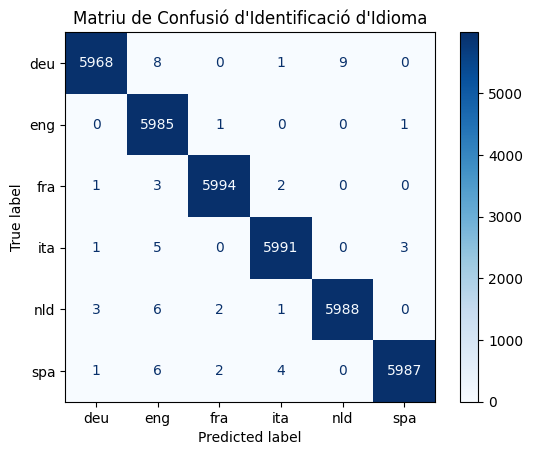

In [7]:
import json
import re
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

def evaluar_modelo(model, test_corpus_json):
    with open(test_corpus_json, 'r', encoding='utf-8') as f:
        test_corpus = json.load(f)

    y_true = []
    y_pred = []
    labels = sorted(list(test_corpus.keys()))

    for lang_true, full_text in test_corpus.items():
        frases = [f.strip() for f in re.split(r' {2,}|\n+', full_text) if len(f.strip()) > 5]

        for frase in frases:
            predicted_lang, _ = model.predict_text(frase)
            y_true.append(lang_true)
            y_pred.append(predicted_lang)

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    print("Report de Classificació:")
    print(classification_report(y_true, y_pred, labels=labels))

    # Visualització Gràfica
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    
    # cmap='Blues' posa el fons blau, values_format='d' assegura que surtin enters i no científic
    disp.plot(cmap='Blues', values_format='d')
    plt.title("Matriu de Confusió d'Identificació d'Idioma")
    plt.show()
    
    return cm

cm = evaluar_modelo(model, './corpus_test.json')


In [ ]:
print(model.predict_text("?"))

('spa', {'ita': -235.67544692722723, 'nld': -263.093072153875, 'deu': -260.0855546223798, 'eng': -254.03015859566628, 'spa': -189.1035800789652, 'fra': -252.53545183500106})


## 2. Interpolation or Laplace smoothing (escull Carlos)